In [1]:
import os
os.listdir()

['Employer Information_2025.csv']

In [2]:
# ============================================================
#  H-1B Employer Data — Exploratory Data Analysis
#  UC Berkeley Data Science Project | Checkpoint 2
#  Dataset: Employer_Information_2025.csv
# ============================================================
 
# ── 0. Install / import libraries ───────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Notebook display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

In [4]:
FILE_PATH = "Employer Information_2025.csv"

df = pd.read_csv(
    FILE_PATH,
    encoding="utf-16",
    sep="\t",
    on_bad_lines="skip",   # skip malformed rows
)
 
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Loaded: 62,324 rows × 20 columns


In [5]:
# ============================================================
#  STEP 2 — Inspect dataset structure
# ============================================================
 
# 2-A. First 5 rows
print("\n ── HEAD ────────────────────────────────────────")
display(df.head()) 

# 2-B. Column names # displays the column names
print("\n ── COLUMNS ─────────────────────────────────────")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")

# 2-C. Data types & non-null counts
print("\n ── INFO ─────────────────────────────────────────")
df.info()

# 2-D. Descriptive statistics
print("\n── DESCRIBE (numeric columns) ───────────────────")
display(df.describe())

# 2-E. Missing values
print("\n── MISSING VALUES ───────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
display(
    pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
    .query("`Missing Count` > 0")
    .sort_values("Missing Count", ascending=False)
)


 ── HEAD ────────────────────────────────────────


,Line by line,Fiscal Year,Employer (Petitioner) Name,Tax ID,Industry (NAICS) Code,Petitioner City,Petitioner State,Petitioner Zip Code,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial
0,1,2025,NaN,NaN,"54 - Professional, Scientific, and Technical S...",FRISCO,TX,"75,034.00",0,0,0,0,0,0,0,0,1,0,0,0
1,2,2025,NaN,274.00,"54 - Professional, Scientific, and Technical S...",GUILFORD,CT,"6,437.00",0,0,1,0,0,0,0,0,0,0,0,0
2,3,2025,NaN,305.00,"54 - Professional, Scientific, and Technical S...",WASHINGTON,DC,"20,001.00",0,0,1,0,0,0,0,0,0,0,0,0
3,4,2025,NaN,"3,188.00","54 - Professional, Scientific, and Technical S...",ARLINGTON,TX,"76,011.00",0,0,0,0,1,0,0,0,0,0,0,0
4,5,2025,NaN,"4,668.00","54 - Professional, Scientific, and Technical S...",CHICAGO,IL,"60,625.00",2,0,0,0,0,0,0,0,0,0,0,0



 ── COLUMNS ─────────────────────────────────────
  01. Line by line
  02. Fiscal Year   
  03. Employer (Petitioner) Name
  04. Tax ID
  05. Industry (NAICS) Code
  06. Petitioner City
  07. Petitioner State
  08. Petitioner Zip Code
  09. New Employment Approval
  10. New Employment Denial
  11. Continuation Approval
  12. Continuation Denial
  13. Change with Same Employer Approval
  14. Change with Same Employer Denial
  15. New Concurrent Approval
  16. New Concurrent Denial
  17. Change of Employer Approval
  18. Change of Employer Denial
  19. Amended Approval
  20. Amended Denial

 ── INFO ─────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62324 entries, 0 to 62323
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Line by line                        62324 non-null  object 
 1   Fiscal Year                         62324 n

,Fiscal Year,Tax ID,Petitioner Zip Code,New Employment Denial,Continuation Denial,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Denial,Amended Denial
count,"62,324.00","62,153.00","62,271.00","62,324.00","62,324.00","62,324.00","62,324.00","62,324.00","62,324.00","62,324.00"
mean,"2,025.00","4,954.96","49,269.23",0.05,0.03,0.01,0.02,0.00,0.02,0.02
std,0.00,"2,897.28","33,140.90",0.44,0.53,0.42,0.26,0.04,0.25,0.91
min,"2,025.00",0.00,610.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"2,025.00","2,422.00","19,006.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,"2,025.00","4,933.00","48,083.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,"2,025.00","7,466.00","79,758.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,"2,025.00","9,999.00","99,901.00",45.00,89.00,66.00,22.00,3.00,27.00,208.00



── MISSING VALUES ───────────────────────────────


,Missing Count,Missing %
Industry (NAICS) Code,3194,5.12
Tax ID,171,0.27
Petitioner Zip Code,53,0.09
Petitioner State,49,0.08
Employer (Petitioner) Name,11,0.02


In [6]:
# ============================================================
#  STEP 3 — Rename columns & create derived columns
# ============================================================
 
# 3-A. Rename for convenience
df = df.rename(columns={
    "Employer (Petitioner) Name" : "employer_name",
    "Industry (NAICS) Code"      : "industry",
    "Petitioner City"            : "city",
    "Petitioner State"           : "state",
    "Petitioner Zip Code"        : "zip",
    "Fiscal Year   "             : "fiscal_year",   # note trailing spaces
})

# 3-B. Cast all approval/denial columns to numeric
approval_cols = [
    "New Employment Approval", "New Employment Denial",
    "Continuation Approval",   "Continuation Denial",
    "Change with Same Employer Approval", "Change with Same Employer Denial",
    "New Concurrent Approval", "New Concurrent Denial",
    "Change of Employer Approval", "Change of Employer Denial",
    "Amended Approval",        "Amended Denial",
]
for col in approval_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# 3-C. Derived columns
approval_sum_cols = [c for c in approval_cols if "Approval" in c]
denial_sum_cols   = [c for c in approval_cols if "Denial"   in c]
 
df["total_approvals"] = df[approval_sum_cols].sum(axis=1)
df["total_denials"]   = df[denial_sum_cols].sum(axis=1)
df["total_cases"]     = df["total_approvals"] + df["total_denials"]
df["approval_rate"]   = (
    df["total_approvals"] / df["total_cases"].replace(0, pd.NA) * 100
).round(2)
 
print("\n── DERIVED COLUMNS — sample ─────────────────────")
display(df[["employer_name", "industry", "state",
            "total_approvals", "total_denials",
            "total_cases", "approval_rate"]].head(10))

# 3-D. Quick overall stats
total_app = df["total_approvals"].sum()
total_den = df["total_denials"].sum()
overall_rate = total_app / (total_app + total_den) * 100
print(f"\n📊 Overall — Approvals: {total_app:,}  |  Denials: {total_den:,}  |  Rate: {overall_rate:.1f}%")


── DERIVED COLUMNS — sample ─────────────────────


,employer_name,industry,state,total_approvals,total_denials,total_cases,approval_rate
0,NaN,"54 - Professional, Scientific, and Technical S...",TX,1,0,1,100.00
1,NaN,"54 - Professional, Scientific, and Technical S...",CT,1,0,1,100.00
2,NaN,"54 - Professional, Scientific, and Technical S...",DC,1,0,1,100.00
3,NaN,"54 - Professional, Scientific, and Technical S...",TX,1,0,1,100.00
4,NaN,"54 - Professional, Scientific, and Technical S...",IL,2,0,2,100.00
5,NaN,"54 - Professional, Scientific, and Technical S...",MA,1,0,1,100.00
6,NaN,"54 - Professional, Scientific, and Technical S...",TX,1,0,1,100.00
7,NaN,72 - Accommodation and Food Services,NM,1,0,1,100.00
8,NaN,"54 - Professional, Scientific, and Technical S...",NV,1,0,1,100.00
9,NaN,"54 - Professional, Scientific, and Technical S...",NY,1,0,1,100.00



📊 Overall — Approvals: 356,864  |  Denials: 8,925  |  Rate: 97.6%


In [7]:
# ============================================================
#  STEP 4 — Key columns for each analysis dimension
# ============================================================
 
print("""
── KEY COLUMNS BY ANALYSIS DIMENSION ────────────────────────
 
  📁 Industry patterns
     - industry               (NAICS code + label)
     - total_approvals / total_denials / approval_rate
 
  🗺️  Geographic patterns
     - state, city, zip
     - total_cases, approval_rate
 
  🏢 Employer sponsorship patterns
     - employer_name
     - total_cases, total_approvals, approval_rate
     - industry, state  (useful for segmenting sponsors)
─────────────────────────────────────────────────────────────
""")
 
# Industry value counts
print("Top 10 Industries (by number of employer rows):")
display(df["industry"].value_counts().head(10).rename("employer_count"))
 
# State value counts
print("\nTop 10 States (by number of employer rows):")
display(df["state"].value_counts().head(10).rename("employer_count"))


── KEY COLUMNS BY ANALYSIS DIMENSION ────────────────────────

  📁 Industry patterns
     - industry               (NAICS code + label)
     - total_approvals / total_denials / approval_rate

  🗺️  Geographic patterns
     - state, city, zip
     - total_cases, approval_rate

  🏢 Employer sponsorship patterns
     - employer_name
     - total_cases, total_approvals, approval_rate
     - industry, state  (useful for segmenting sponsors)
─────────────────────────────────────────────────────────────

Top 10 Industries (by number of employer rows):


industry
54 - Professional, Scientific, and Technical Services                            25535
31-33 - Manufacturing                                                             6822
62 - Health Care and Social Assistance                                            5487
52 - Finance and Insurance                                                        3769
51 - Information                                                                  3424
61 - Educational Services                                                         3333
42 - Wholesale Trade                                                              1952
23 - Construction                                                                 1655
44-45 - Retail Trade                                                              1546
56 - Administrative and Support and Waste Management and Remediation Services      991
Name: employer_count, dtype: int64


Top 10 States (by number of employer rows):


state
CA    11123
TX     6859
NY     6689
NJ     3824
IL     3009
FL     2881
MA     2869
VA     2128
GA     2118
MI     1980
Name: employer_count, dtype: int64

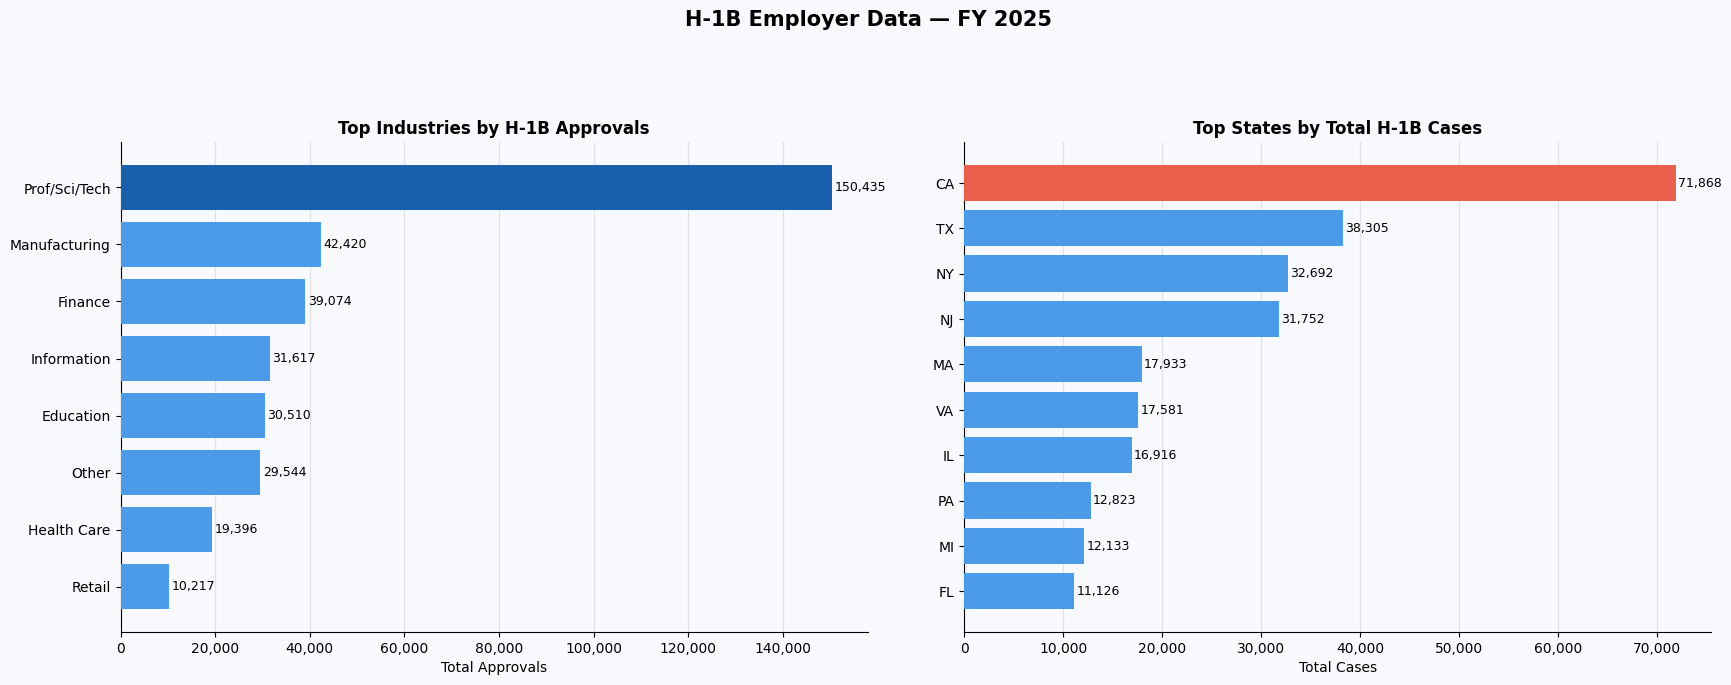

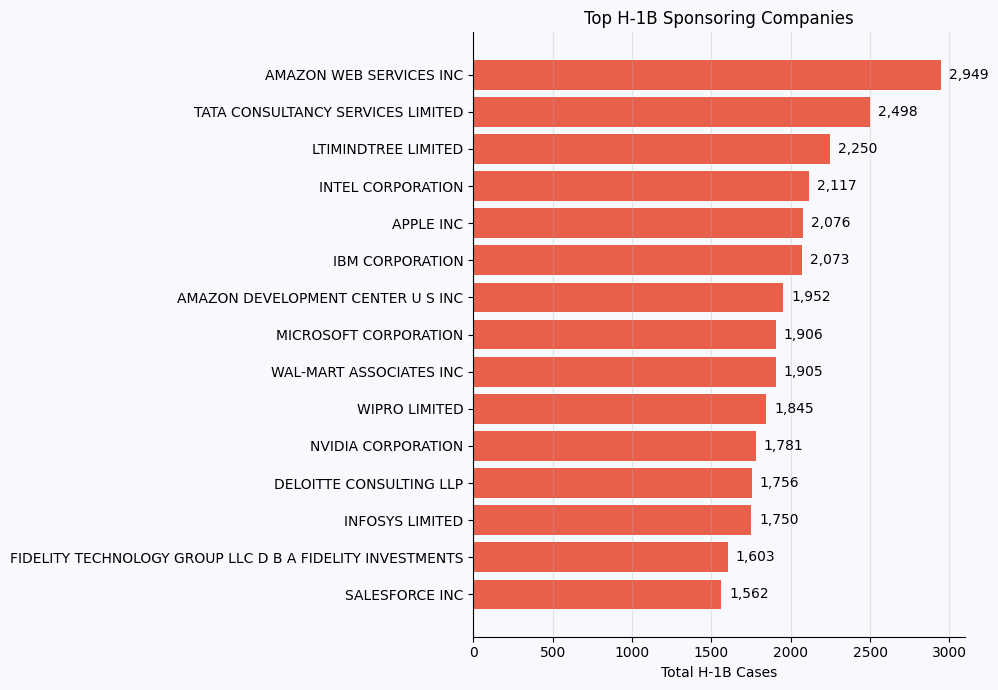

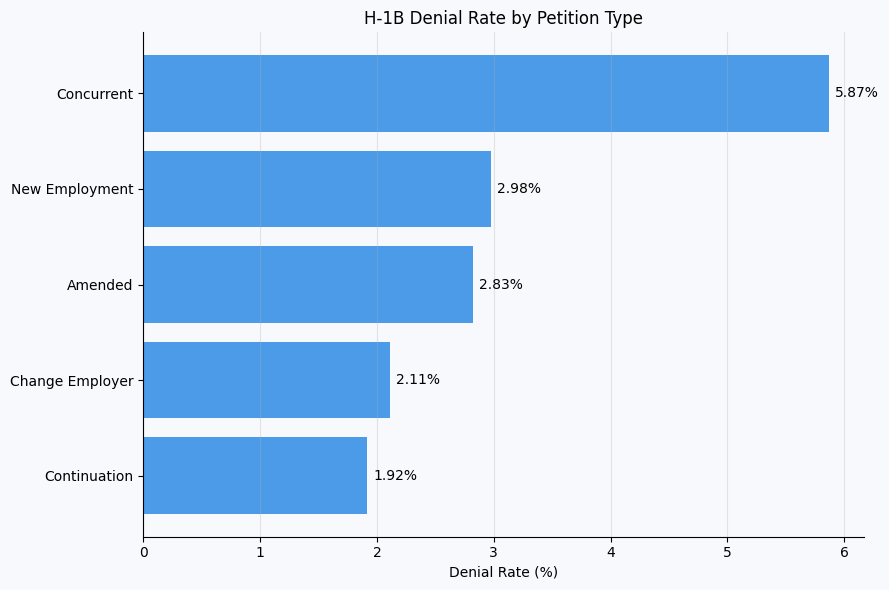

✅ Visualization saved as h1b_eda_viz.png


In [15]:
# ============================================================
#  STEP 5 — Visualizations
# ============================================================
 
# ── Helper: short industry labels ───────────────────────────
INDUSTRY_LABELS = {
    "54 - Professional, Scientific, and Technical Services" : "Prof/Sci/Tech",
    "31-33 - Manufacturing"                                 : "Manufacturing",
    "62 - Health Care and Social Assistance"                : "Health Care",
    "52 - Finance and Insurance"                            : "Finance",
    "51 - Information"                                      : "Information",
    "72 - Accommodation and Food Services"                  : "Accom/Food",
    "61 - Educational Services"                             : "Education",
    "56 - Administrative and Support Services"              : "Admin Support",
    "44-45 - Retail Trade"                                  : "Retail",
    "48-49 - Transportation and Warehousing"                : "Transport",
}
df["industry_short"] = df["industry"].map(INDUSTRY_LABELS).fillna("Other")
 
# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "#F7F9FC",
    "axes.facecolor"   : "#F7F9FC",
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("H-1B Employer Data — FY 2025", fontsize=15, fontweight="bold", y=1.01)
 
# ── VIZ 1: Top industries by total approvals ─────────────────
ind_agg = (
    df.groupby("industry_short")["total_approvals"]
    .sum()
    .nlargest(8)
    .sort_values()
)
 
colors_ind = ["#4C9BE8" if v < ind_agg.max() else "#1A5FAD" for v in ind_agg.values]
bars1 = axes[0].barh(ind_agg.index, ind_agg.values, color=colors_ind, zorder=3)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].set_title("Top Industries by H-1B Approvals", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Total Approvals")
axes[0].grid(axis="x", alpha=0.3, zorder=0)
for bar, val in zip(bars1, ind_agg.values):
    axes[0].text(val + 500, bar.get_y() + bar.get_height() / 2,
                 f"{int(val):,}", va="center", fontsize=9)
 
# ── VIZ 2: Top states by total H-1B cases ────────────────────
state_agg = (
    df.groupby("state")["total_cases"]
    .sum()
    .nlargest(10)
    .sort_values()
)
 
colors_state = ["#E8604C" if s == state_agg.idxmax() else "#4C9BE8"
                for s in state_agg.index]
bars2 = axes[1].barh(state_agg.index, state_agg.values, color=colors_state, zorder=3)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[1].set_title("Top States by Total H-1B Cases", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total Cases")
axes[1].grid(axis="x", alpha=0.3, zorder=0)
for bar, val in zip(bars2, state_agg.values):
    axes[1].text(val + 200, bar.get_y() + bar.get_height() / 2,
                 f"{int(val):,}", va="center", fontsize=9)
 
plt.tight_layout(pad=3)
plt.show()

# ── VIZ 3: Top H1B Sponsoring Companies ───────────────────

top_employers = (
    df.groupby("employer_name")["total_cases"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10,7))

bars = plt.barh(
    top_employers.index,
    top_employers.values,
    color="#E8604C"
)

plt.xlabel("Total H-1B Cases")
plt.title("Top H-1B Sponsoring Companies")

plt.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, top_employers.values):
    plt.text(val + 50,
             bar.get_y() + bar.get_height()/2,
             f"{int(val):,}",
             va="center")

plt.tight_layout()
plt.show()

# ── VIZ 4: Denial Rate by Petition Type ───────────────────

petition_types = {
    "New Employment": ["New Employment Approval","New Employment Denial"],
    "Continuation": ["Continuation Approval","Continuation Denial"],
    "Change Employer": ["Change of Employer Approval","Change of Employer Denial"],
    "Concurrent": ["New Concurrent Approval","New Concurrent Denial"],
    "Amended": ["Amended Approval","Amended Denial"]
}

denial_rates = {}

for k, cols in petition_types.items():
    approvals = df[cols[0]].sum()
    denials   = df[cols[1]].sum()
    denial_rates[k] = denials / (approvals + denials) * 100

denial_rates = pd.Series(denial_rates).sort_values()

plt.figure(figsize=(9,6))

bars = plt.barh(
    denial_rates.index,
    denial_rates.values,
    color="#4C9BE8"
)

plt.xlabel("Denial Rate (%)")
plt.title("H-1B Denial Rate by Petition Type")

plt.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, denial_rates.values):
    plt.text(val + 0.05,
             bar.get_y() + bar.get_height()/2,
             f"{val:.2f}%",
             va="center")

plt.tight_layout()
plt.show()

print("✅ Visualization saved as h1b_eda_viz.png")

In [18]:
# ============================================================
# STEP 6 — Questions that we can explore based on the dataset 
# ============================================================

# 1. Why does the technology sector rely disproportionately on H-1B workers compared to other industries?
#    Detailed version 
#    (Is the heavy reliance on H-1B workers in the technology sector driven primarily 
#     by skill shortages, industry globalization, or the outsourcing business model?)

# 2. Does the low denial rate in USCIS petition data accurately represent the true difficulty of obtaining an H-1B visa?
# Context
# The visualization shows that denial rates across different H-1B petition types are relatively low, generally below 6%. 
# At first glance, this could suggest that obtaining an H-1B visa is not particularly difficult. 
# However, the USCIS petition dataset only includes applications that have already passed the H-1B lottery stage. 
# Because the lottery significantly reduces the number of applicants before petitions are reviewed, the dataset represents a pre-selected group of candidates. 
# As a result, the observed denial rates may not fully capture the overall difficulty of obtaining an H-1B visa. 
# Incorporating lottery selection data could provide a more accurate picture of the true probability of successfully obtaining an H-1B visa.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=299a6352-7284-48f9-9b28-3661e9f11c40' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>